# Coarse level clustering and annotation for discovery cohort

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad
import muon as mu
import celltypist as ct
from sklearn_ann.kneighbors.annoy import AnnoyTransformer

In [ ]:
results_dir = "../results/tables/cite_seq/cohort_treatment_naive/cluster_annotate"
os.makedirs(results_dir, exist_ok=True)

# Load MuData

MuData object generated by running Snakemake workflows in `01_prepare_internal_datasets`, then `slurm/convert_seurat_scanpy_cohort_treatment_naive.sh`.

In [3]:
mdata = mu.read_h5mu("../data/processed/cite_seq/cohort_treatment_naive/cellbender/multi/peak-method:None_b:False_d:False/n-features:5000_normalisation:LogNormalize_clr:seurat_M:True_C:True/batch:orig.ident_normalisation:LogNormalize_integration:harmony/integrated.h5mu", backed=True)

In [4]:
mdata

MuData object with n_obs × n_vars = 279855 × 26584 backed at '../data/processed/cite_seq/cohort_treatment_naive/cellbender/multi/peak-method:None_b:False_d:False/n-features:5000_normalisation:LogNormalize_clr:seurat_M:True_C:True/batch:orig.ident_normalisation:LogNormalize_integration:harmony/integrated.h5mu'
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample_id', 'hash_id', 'donor', 'processing_batch', 'experiment', 'chemistry', 'hto_panel', 'adt_panel', 'nCount_ADT', 'nFeature_ADT', 'pctMito_RNA', 'S.Score', 'G2M.Score', 'Phase', 'batch'
  var:	'var.features', 'var.features.rank'
  2 modalities
    RNA:	279855 x 26424
      var:	'ensembl_id', 'gene_symbol', 'gene_type', 'vf_vst_counts.OCRZ003-A_mean', 'vf_vst_counts.OCRZ003-A_variance', 'vf_vst_counts.OCRZ003-A_variance.expected', 'vf_vst_counts.OCRZ003-A_variance.standardized', 'vf_vst_counts.OCRZ003-A_variable', 'vf_vst_counts.OCRZ003-A_rank', 'vf_vst_counts.OCRZ003-B_mean', 'vf_vst_counts.OCRZ003-B_variance', 'vf_vst_counts.OCRZ003-B_variance.expected', 'vf_vst_counts.OCRZ003-B_variance.standardized', 'vf_vst_counts.OCRZ003-B_variable', 'vf_vst_counts.OCRZ003-B_rank', 'vf_vst_counts.OCRZ003-C_mean', 'vf_vst_counts.OCRZ003-C_variance', 'vf_vst_counts.OCRZ003-C_variance.expected', 'vf_vst_counts.OCRZ003-C_variance.standardized', 'vf_vst_counts.OCRZ003-C_variable', 'vf_vst_counts.OCRZ003-C_rank', 'vf_vst_counts.OCRZ004-A_mean', 'vf_vst_counts.OCRZ004-A_variance', 'vf_vst_counts.OCRZ004-A_variance.expected', 'vf_vst_counts.OCRZ004-A_variance.standardized', 'vf_vst_counts.OCRZ004-A_variable', 'vf_vst_counts.OCRZ004-A_rank', 'vf_vst_counts.OCRZ004-B_mean', 'vf_vst_counts.OCRZ004-B_variance', 'vf_vst_counts.OCRZ004-B_variance.expected', 'vf_vst_counts.OCRZ004-B_variance.standardized', 'vf_vst_counts.OCRZ004-B_variable', 'vf_vst_counts.OCRZ004-B_rank', 'vf_vst_counts.OCRZ004-C_mean', 'vf_vst_counts.OCRZ004-C_variance', 'vf_vst_counts.OCRZ004-C_variance.expected', 'vf_vst_counts.OCRZ004-C_variance.standardized', 'vf_vst_counts.OCRZ004-C_variable', 'vf_vst_counts.OCRZ004-C_rank', 'vf_vst_counts.OCRZ011-A_mean', 'vf_vst_counts.OCRZ011-A_variance', 'vf_vst_counts.OCRZ011-A_variance.expected', 'vf_vst_counts.OCRZ011-A_variance.standardized', 'vf_vst_counts.OCRZ011-A_variable', 'vf_vst_counts.OCRZ011-A_rank', 'vf_vst_counts.OCRZ011-B_mean', 'vf_vst_counts.OCRZ011-B_variance', 'vf_vst_counts.OCRZ011-B_variance.expected', 'vf_vst_counts.OCRZ011-B_variance.standardized', 'vf_vst_counts.OCRZ011-B_variable', 'vf_vst_counts.OCRZ011-B_rank', 'vf_vst_counts.OCRZ011-C_mean', 'vf_vst_counts.OCRZ011-C_variance', 'vf_vst_counts.OCRZ011-C_variance.expected', 'vf_vst_counts.OCRZ011-C_variance.standardized', 'vf_vst_counts.OCRZ011-C_variable', 'vf_vst_counts.OCRZ011-C_rank', 'vf_vst_counts.OCRZ012-A_mean', 'vf_vst_counts.OCRZ012-A_variance', 'vf_vst_counts.OCRZ012-A_variance.expected', 'vf_vst_counts.OCRZ012-A_variance.standardized', 'vf_vst_counts.OCRZ012-A_variable', 'vf_vst_counts.OCRZ012-A_rank', 'vf_vst_counts.OCRZ012-B_mean', 'vf_vst_counts.OCRZ012-B_variance', 'vf_vst_counts.OCRZ012-B_variance.expected', 'vf_vst_counts.OCRZ012-B_variance.standardized', 'vf_vst_counts.OCRZ012-B_variable', 'vf_vst_counts.OCRZ012-B_rank', 'vf_vst_counts.OCRZ012-C_mean', 'vf_vst_counts.OCRZ012-C_variance', 'vf_vst_counts.OCRZ012-C_variance.expected', 'vf_vst_counts.OCRZ012-C_variance.standardized', 'vf_vst_counts.OCRZ012-C_variable', 'vf_vst_counts.OCRZ012-C_rank', 'vf_vst_counts.OCRZ013-B_mean', 'vf_vst_counts.OCRZ013-B_variance', 'vf_vst_counts.OCRZ013-B_variance.expected', 'vf_vst_counts.OCRZ013-B_variance.standardized', 'vf_vst_counts.OCRZ013-B_variable', 'vf_vst_counts.OCRZ013-B_rank', 'vf_vst_counts.OCRZ013-C_mean', 'vf_vst_counts.OCRZ013-C_variance', 'vf_vst_counts.OCRZ013-C_variance.expected', 'vf_vst_counts.OCRZ013-C_variance.standardized', 'vf_vst_counts.OCRZ013-C_variable', 'vf_vst_counts.OCRZ013-C_rank', 'vf_vst_counts.OCRZ014-D_mean', 'vf_vst_counts.OCRZ014-D_variance', 'vf_vst_counts.OCRZ014-

# Compute doublet scores

In [5]:
adata = mdata["RNA"].to_memory().copy()
adata.obs = mdata.obs.copy()
adata.X = adata.layers["counts"]

In [6]:
sc.pp.scrublet(
    adata,
    batch_key="batch",
    use_approx_neighbors=True,   
)

In [7]:
doublet_scores = adata.obs["doublet_score"].copy()
mdata.obs["doublet_scores"] = doublet_scores
doublet_scores.to_csv(os.path.join(results_dir, "doublet_scores.tsv"), sep="\t", index=True)

In [8]:
del adata, doublet_scores

# Compute nearest neighbors, UMAP embedding and multi-resolution Leiden clustering for each modality

In [9]:
for mod in mdata.mod_names:
    print(f"Processing modality: {mod}")
    print("    Computing neighbors...")
    sc.pp.neighbors(mdata[mod], transformer=AnnoyTransformer(n_neighbors=30, metric="angular"), use_rep="integrated." + mod.lower())
    print("    Computing UMAP...")
    sc.tl.umap(mdata[mod])
    print("    Computing Leiden clustering...")
    for res in range(1, 10):
        print(f"        Resolution: {res}")
        sc.tl.leiden(mdata[mod], resolution=res, key_added=f"leiden_{res}", flavor="igraph", n_iterations=2)

Processing modality: RNA
    Computing neighbors...
    Computing UMAP...
    Computing Leiden clustering...
        Resolution: 1
        Resolution: 2
        Resolution: 3
        Resolution: 4
        Resolution: 5
        Resolution: 6
        Resolution: 7
        Resolution: 8
        Resolution: 9
Processing modality: ADT
    Computing neighbors...
    Computing UMAP...
    Computing Leiden clustering...
        Resolution: 1
        Resolution: 2
        Resolution: 3
        Resolution: 4
        Resolution: 5
        Resolution: 6
        Resolution: 7
        Resolution: 8
        Resolution: 9


### Check batch correction for each modality

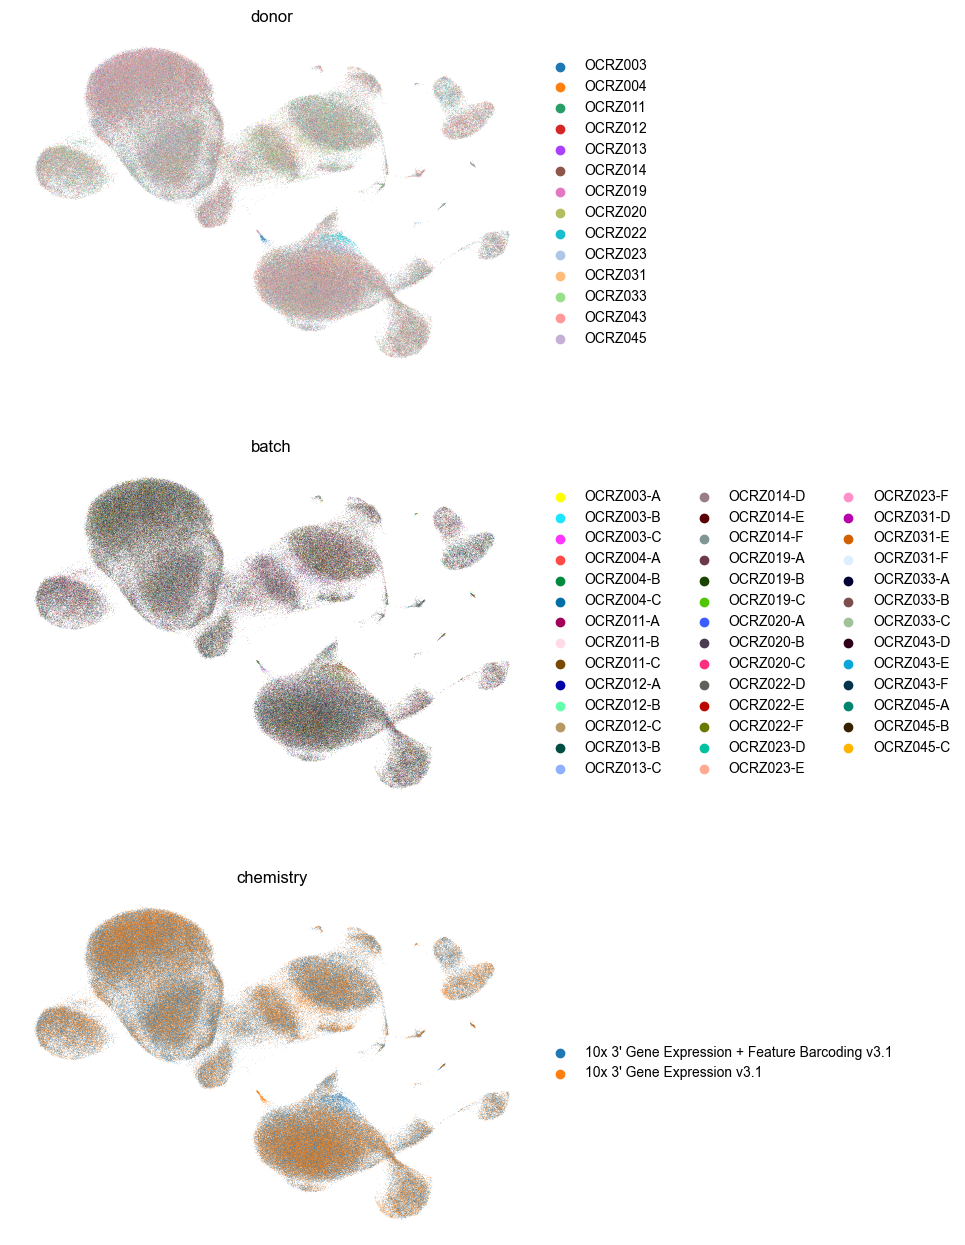

In [10]:
mu.pl.embedding(
    mdata,
    basis="RNA:X_umap",
    color=["donor", "batch", "chemistry"],
    frameon=False,
    ncols=1,
)

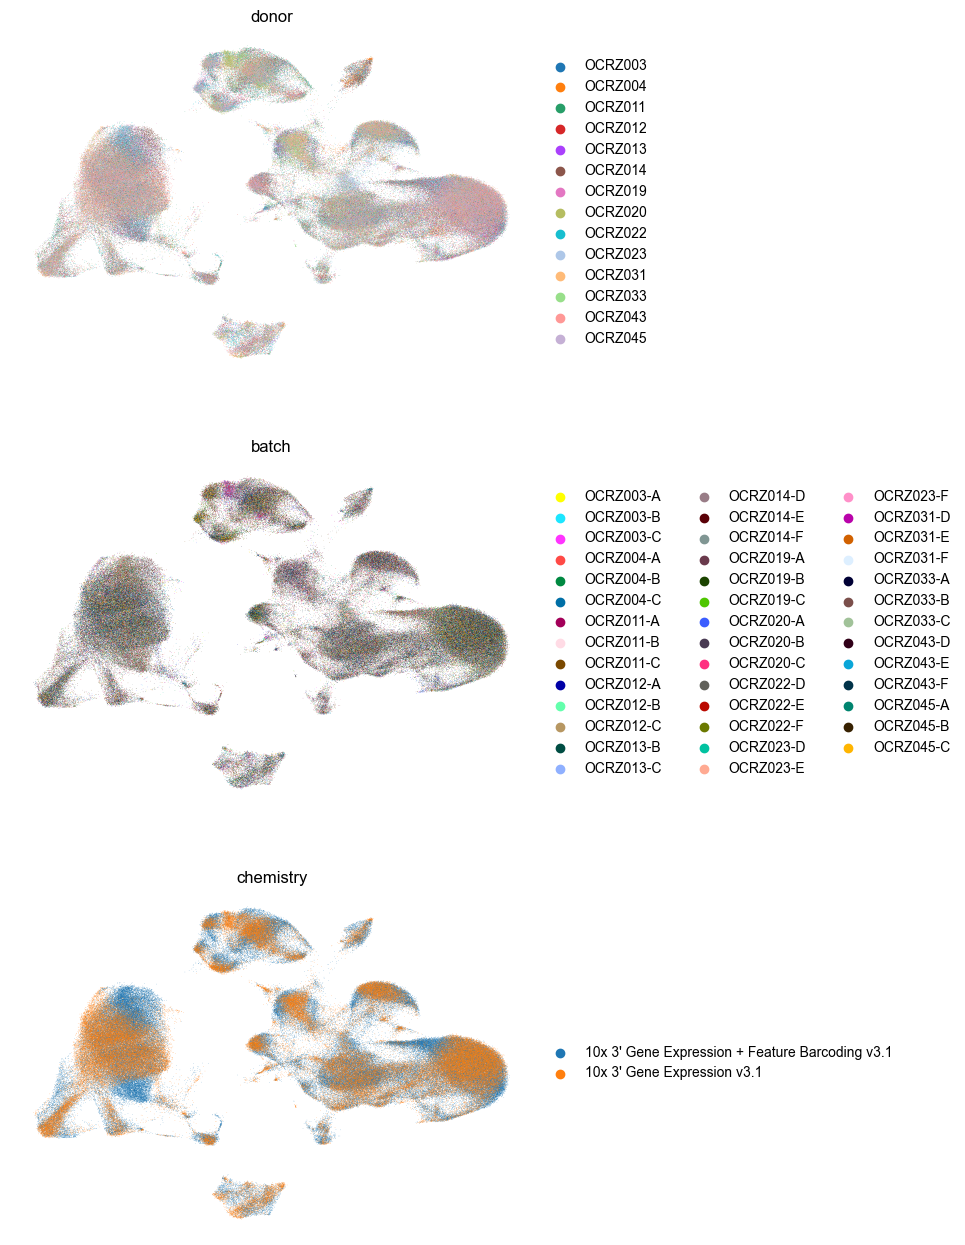

In [11]:
mu.pl.embedding(
    mdata,
    basis="ADT:X_umap",
    color=["donor", "batch", "chemistry"],
    frameon=False,
    ncols=1,
)

### Check doublet scores

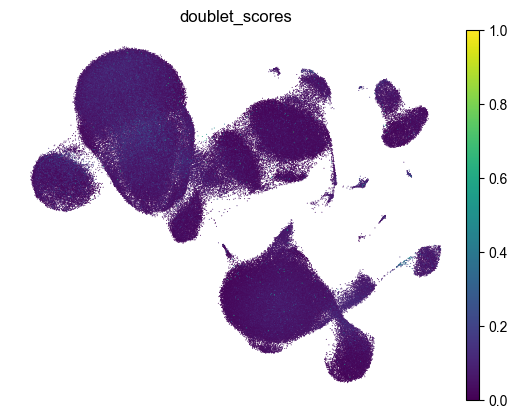

In [12]:
mu.pl.embedding(
    mdata,
    basis="RNA:X_umap",
    color="doublet_scores",
    frameon=False,
    ncols=1,
    vmin=0,
    vmax=1,
    cmap="viridis",
    size=2,
)

### Check clustering for each modality

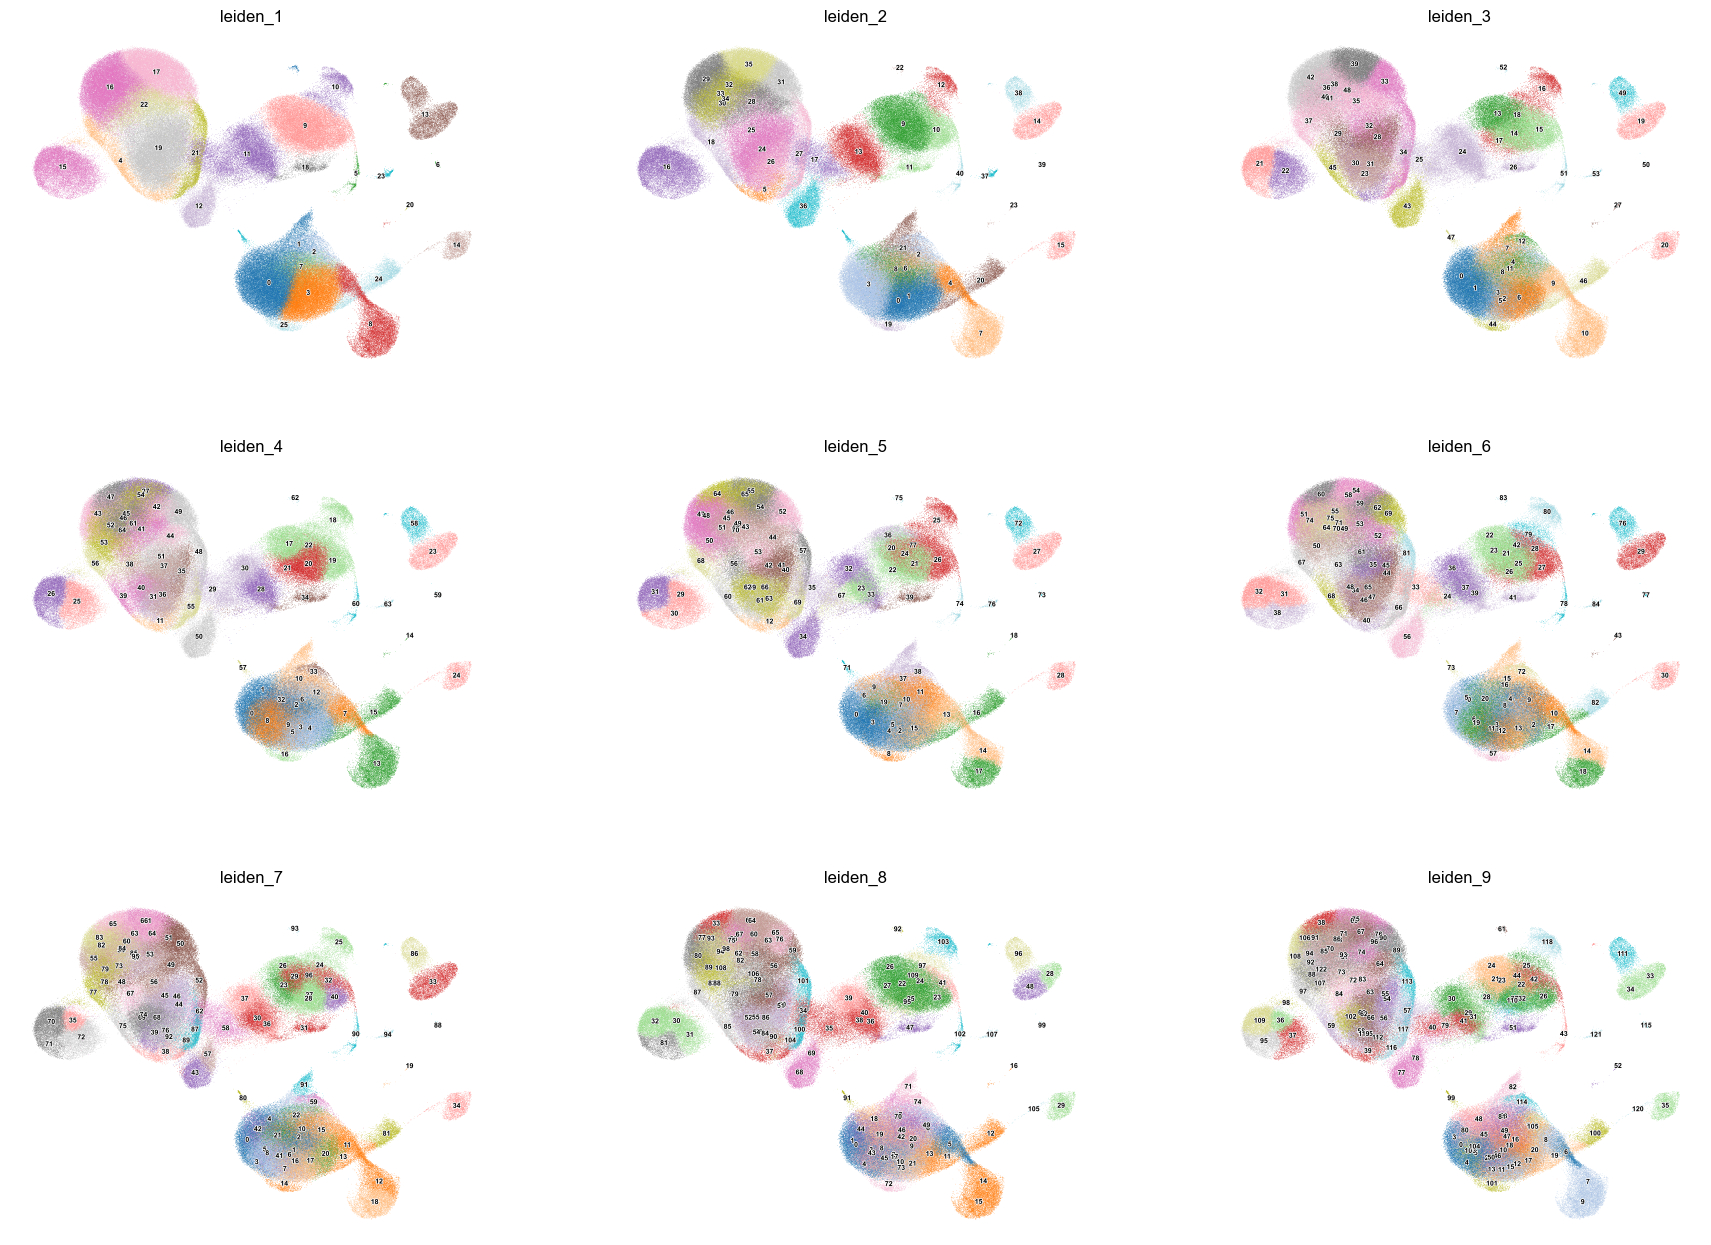

In [13]:
sc.pl.umap(
    mdata["RNA"],
    color=[f"leiden_{res}" for res in range(1, 10)],
    palette="tab20",
    frameon=False,
    legend_loc="on data",
    legend_fontoutline=1,
    legend_fontsize=5,
    ncols=3,
)

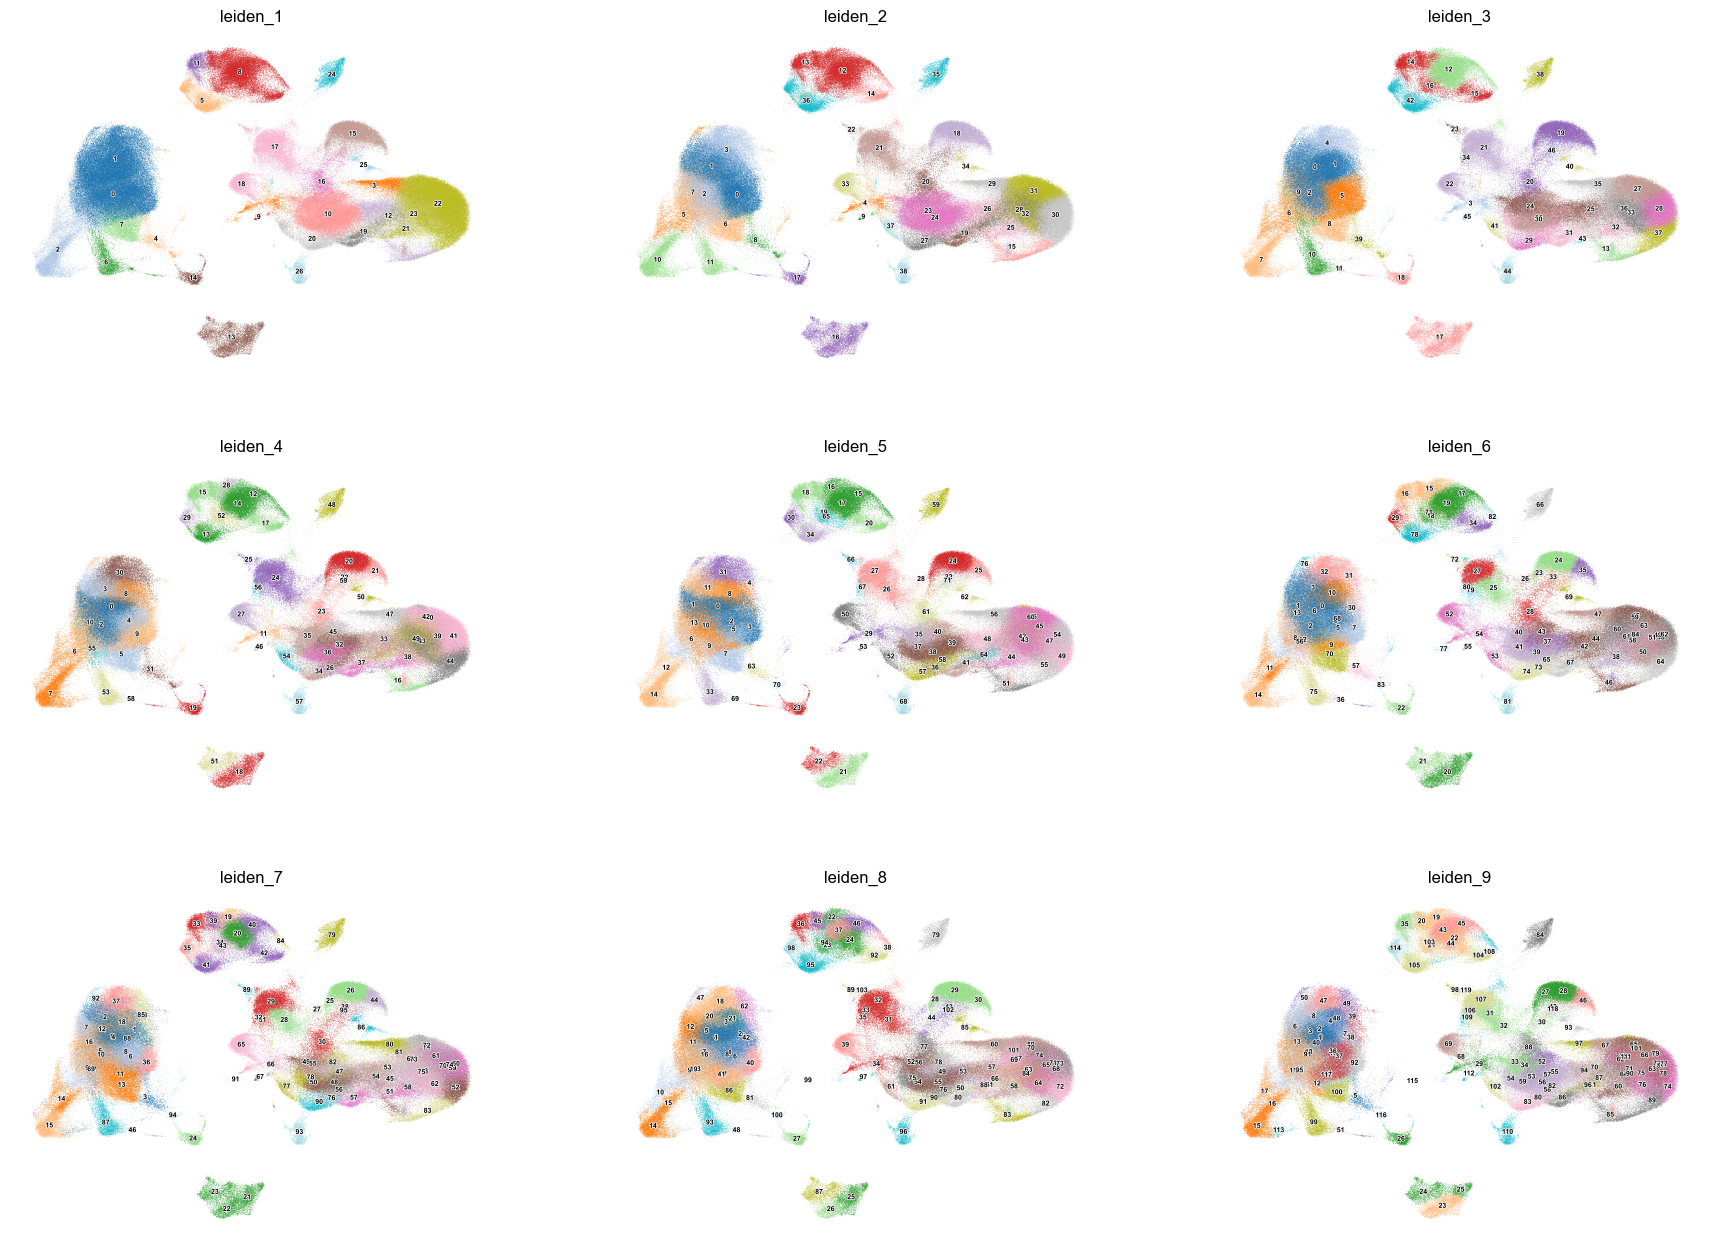

In [14]:
sc.pl.umap(
    mdata["ADT"],
    color=[f"leiden_{res}" for res in range(1, 10)],
    palette="tab20",
    frameon=False,
    legend_loc="on data",
    legend_fontoutline=1,
    legend_fontsize=5,
    ncols=3,
)

# Run CellTypist annotation

CellTypist models downloaded from https://apps.allenimmunology.org/aifi/resources/imm-health-atlas/downloads/models/

In [ ]:
models_dir = "../data/ref/celltypist_models"
models_dict = {
    "L1": os.path.join(models_dir, "ref_pbmc_clean_celltypist_model_AIFI_L1_2024-04-18.pkl"),
    "L2": os.path.join(models_dir, "ref_pbmc_clean_celltypist_model_AIFI_L2_2024-04-19.pkl"),
    "L3": os.path.join(models_dir, "ref_pbmc_clean_celltypist_model_AIFI_L3_2024-04-19.pkl"),
}
models = {name: ct.models.Model.load(path) for name, path in models_dict.items()}

In [8]:
celltypist_results = {}
for name, model in models.items():
    print(f"Running CellTypist using model: {name}")
    celltypist_results[name] = ct.annotate(mdata["RNA"], model)

Running CellTypist using model: L1


🔬 Input data has 279855 cells and 26424 genes
🔗 Matching reference genes in the model
🧬 1061 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


Running CellTypist using model: L2


🔬 Input data has 279855 cells and 26424 genes
🔗 Matching reference genes in the model
🧬 1838 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


Running CellTypist using model: L3


🔬 Input data has 279855 cells and 26424 genes
🔗 Matching reference genes in the model
🧬 2369 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


In [9]:
celltypist_annotation = pd.DataFrame(
    {
        name: results.predicted_labels["predicted_labels"]
        for name, results in celltypist_results.items()
    },
    index=mdata["RNA"].obs_names,
)

In [10]:
celltypist_annotation.to_csv(os.path.join(results_dir, "celltypist_annotation.tsv"), sep="\t", index=True, header=True)

# Load precomputed reference-based cell type annotations

Azimuth annotations generated by running `slurm/reference_map_cohort_treatment_naive.sh` (reference dataset downloaded from https://zenodo.org/records/7779017)
SingleR annotations generated by running `slurm/singler_annotation_cohort_treatment_naive.sh` (reference dataset downloaded within the script)

In [15]:
celltypist_annotation = pd.read_csv(os.path.join(results_dir, "celltypist_annotation.tsv"), sep="\t", index_col=0).rename(columns=lambda x: f"celltypist_{x}")
azimuth_annotation = pd.read_csv(os.path.join(results_dir, "reference_map.tsv"), sep="\t", index_col=0).rename(columns=lambda x: f"azimuth_{x}")
singler_annotation = pd.read_csv(os.path.join(results_dir, "singler_annotation.tsv"), sep="\t", index_col=0).rename(columns=lambda x: f"singler_{x}")
annotation = pd.concat([celltypist_annotation, azimuth_annotation, singler_annotation], axis=1)

In [16]:
for col in annotation.columns:
    mdata.obs[col] = pd.Categorical(annotation[col])

### Check annotations

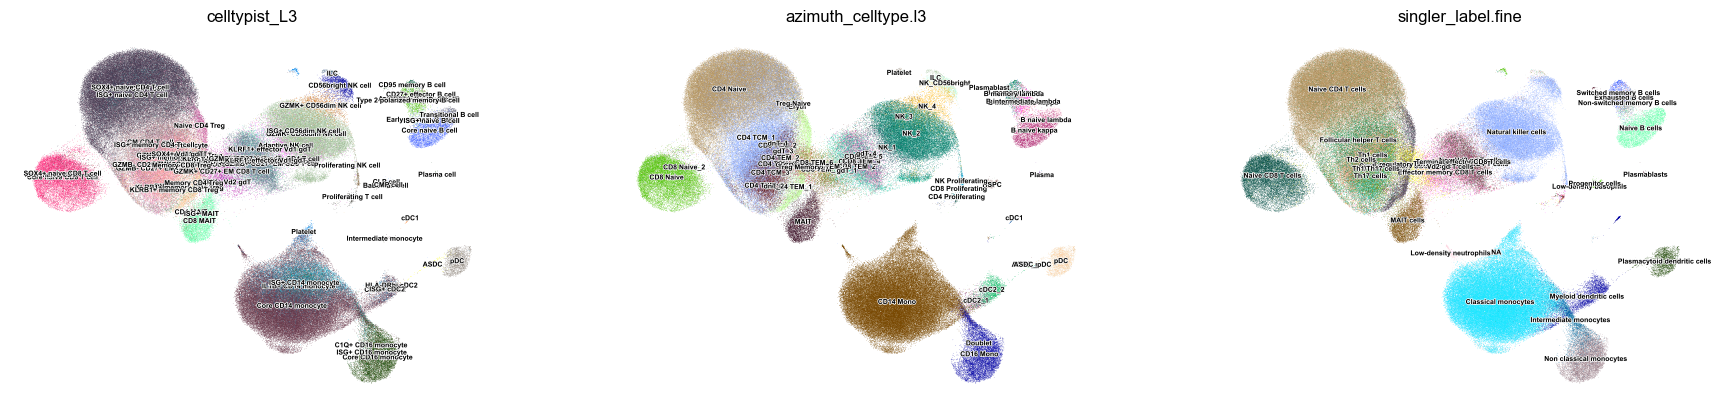

In [17]:
mu.pl.embedding(
    mdata,
    basis="RNA:X_umap",
    color=["celltypist_L3", "azimuth_celltype.l3", "singler_label.fine"],
    frameon=False,
    legend_loc="on data",
    legend_fontoutline=1,
    legend_fontsize=5,
    ncols=3,
)

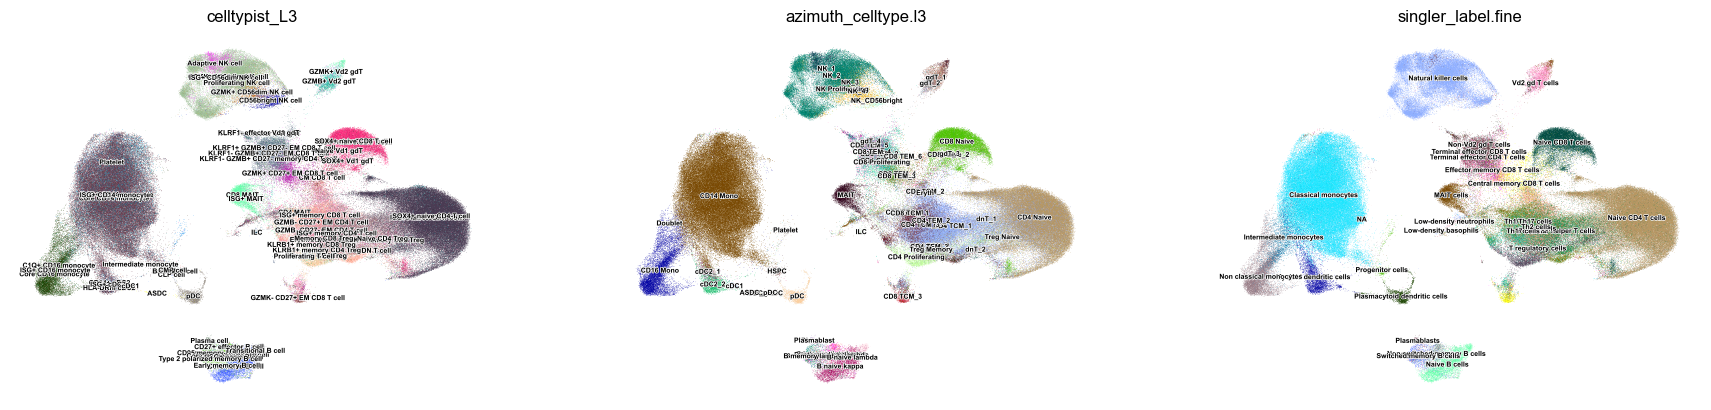

In [18]:
mu.pl.embedding(
    mdata,
    basis="ADT:X_umap",
    color=["celltypist_L3", "azimuth_celltype.l3", "singler_label.fine"],
    frameon=False,
    legend_loc="on data",
    legend_fontoutline=1,
    legend_fontsize=5,
    ncols=3,
)

# Save clustered and annotated MuData object

In [19]:
mdata

MuData object with n_obs × n_vars = 279855 × 26584 backed at '../data/processed/cite_seq/cohort_treatment_naive/cellbender/multi/peak-method:None_b:False_d:False/n-features:5000_normalisation:LogNormalize_clr:seurat_M:True_C:True/batch:orig.ident_normalisation:LogNormalize_integration:harmony/integrated.h5mu'
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample_id', 'hash_id', 'donor', 'processing_batch', 'experiment', 'chemistry', 'hto_panel', 'adt_panel', 'nCount_ADT', 'nFeature_ADT', 'pctMito_RNA', 'S.Score', 'G2M.Score', 'Phase', 'batch', 'doublet_scores', 'celltypist_L1', 'celltypist_L2', 'celltypist_L3', 'azimuth_celltype.l1', 'azimuth_celltype.l2', 'azimuth_celltype.l3', 'singler_label.main', 'singler_label.fine'
  var:	'var.features', 'var.features.rank'
  2 modalities
    RNA:	279855 x 26424
      obs:	'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_5', 'leiden_6', 'leiden_7', 'leiden_8', 'leiden_9'
      var:	'ensembl_id', 'gene_symbol', 'gene_type', 'vf_vst_counts.OCRZ003-A_mean', 'vf_vst_counts.OCRZ003-A_variance', 'vf_vst_counts.OCRZ003-A_variance.expected', 'vf_vst_counts.OCRZ003-A_variance.standardized', 'vf_vst_counts.OCRZ003-A_variable', 'vf_vst_counts.OCRZ003-A_rank', 'vf_vst_counts.OCRZ003-B_mean', 'vf_vst_counts.OCRZ003-B_variance', 'vf_vst_counts.OCRZ003-B_variance.expected', 'vf_vst_counts.OCRZ003-B_variance.standardized', 'vf_vst_counts.OCRZ003-B_variable', 'vf_vst_counts.OCRZ003-B_rank', 'vf_vst_counts.OCRZ003-C_mean', 'vf_vst_counts.OCRZ003-C_variance', 'vf_vst_counts.OCRZ003-C_variance.expected', 'vf_vst_counts.OCRZ003-C_variance.standardized', 'vf_vst_counts.OCRZ003-C_variable', 'vf_vst_counts.OCRZ003-C_rank', 'vf_vst_counts.OCRZ004-A_mean', 'vf_vst_counts.OCRZ004-A_variance', 'vf_vst_counts.OCRZ004-A_variance.expected', 'vf_vst_counts.OCRZ004-A_variance.standardized', 'vf_vst_counts.OCRZ004-A_variable', 'vf_vst_counts.OCRZ004-A_rank', 'vf_vst_counts.OCRZ004-B_mean', 'vf_vst_counts.OCRZ004-B_variance', 'vf_vst_counts.OCRZ004-B_variance.expected', 'vf_vst_counts.OCRZ004-B_variance.standardized', 'vf_vst_counts.OCRZ004-B_variable', 'vf_vst_counts.OCRZ004-B_rank', 'vf_vst_counts.OCRZ004-C_mean', 'vf_vst_counts.OCRZ004-C_variance', 'vf_vst_counts.OCRZ004-C_variance.expected', 'vf_vst_counts.OCRZ004-C_variance.standardized', 'vf_vst_counts.OCRZ004-C_variable', 'vf_vst_counts.OCRZ004-C_rank', 'vf_vst_counts.OCRZ011-A_mean', 'vf_vst_counts.OCRZ011-A_variance', 'vf_vst_counts.OCRZ011-A_variance.expected', 'vf_vst_counts.OCRZ011-A_variance.standardized', 'vf_vst_counts.OCRZ011-A_variable', 'vf_vst_counts.OCRZ011-A_rank', 'vf_vst_counts.OCRZ011-B_mean', 'vf_vst_counts.OCRZ011-B_variance', 'vf_vst_counts.OCRZ011-B_variance.expected', 'vf_vst_counts.OCRZ011-B_variance.standardized', 'vf_vst_counts.OCRZ011-B_variable', 'vf_vst_counts.OCRZ011-B_rank', 'vf_vst_counts.OCRZ011-C_mean', 'vf_vst_counts.OCRZ011-C_variance', 'vf_vst_counts.OCRZ011-C_variance.expected', 'vf_vst_counts.OCRZ011-C_variance.standardized', 'vf_vst_counts.OCRZ011-C_variable', 'vf_vst_counts.OCRZ011-C_rank', 'vf_vst_counts.OCRZ012-A_mean', 'vf_vst_counts.OCRZ012-A_variance', 'vf_vst_counts.OCRZ012-A_variance.expected', 'vf_vst_counts.OCRZ012-A_variance.standardized', 'vf_vst_counts.OCRZ012-A_variable', 'vf_vst_counts.OCRZ012-A_rank', 'vf_vst_counts.OCRZ012-B_mean', 'vf_vst_counts.OCRZ012-B_variance', 'vf_vst_counts.OCRZ012-B_variance.expected', 'vf_vst_counts.OCRZ012-B_variance.standardized', 'vf_vst_counts.OCRZ012-B_variable', 'vf_vst_counts.OCRZ012-B_rank', 'vf_vst_counts.OCRZ012-C_mean', 'vf_vst_counts.OCRZ012-C_variance', 'vf_vst_counts.OCRZ012-C_variance.expected', 'vf_vst_counts.OCRZ012-C_variance.standardized', 'vf_vst_counts.OCRZ012-C_variable', 'vf_vst_counts.OCRZ012-C_rank', 'vf_vst_counts.OCRZ013-B_mean', 'vf_vst_counts.OCRZ013-B_variance', 'vf_vst_counts.OCRZ013-B_variance.expected', 'vf_vst_counts.OCRZ013-B_variance.standardized', 'vf_vst_counts.OCRZ013-B_variable', 'vf_vst_counts.OCRZ013-B_rank', 'vf_vst_counts.OCRZ01

In [20]:
mdata.write_h5mu(os.path.join(results_dir, "clustered_annotated.h5mu"), compression="gzip")

... storing 'var.features' as categorical


# Load scTriangulate results

scTriangulate results generated by running `slurm/run_sctriangulate_cohort_treatment_naive.sh`

In [3]:
adata = ad.read_h5ad(os.path.join(results_dir, "sctriangulate", "sctriangulate.h5ad"))

### Visualise pruned clusters

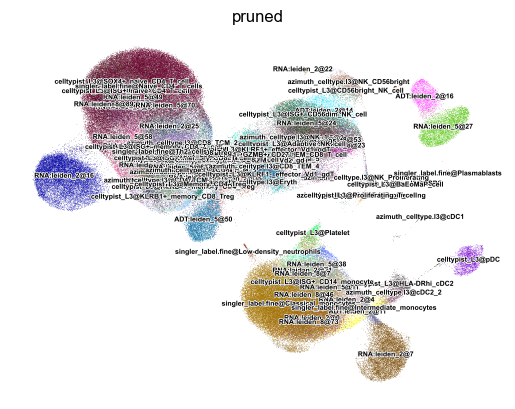

In [4]:
sc.pl.umap(
    adata,
    color="pruned",
    frameon=False,
    legend_loc="on data",
    legend_fontoutline=1,
    legend_fontsize=5,
    ncols=1,
)

### Cross-tabulate pruned clusters with reference-based annotations

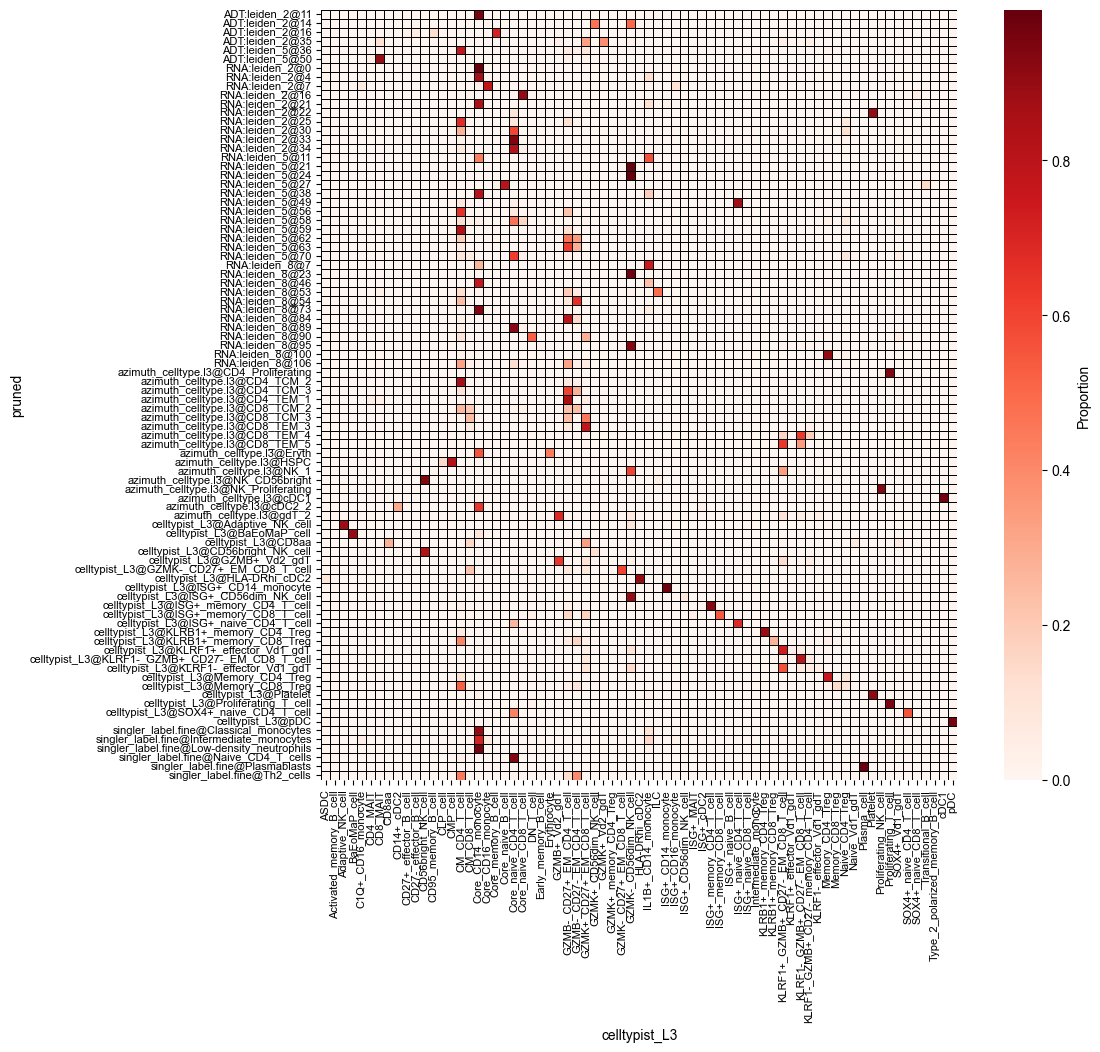

In [5]:
ct = pd.crosstab(adata.obs["pruned"], adata.obs["celltypist_L3"], normalize="index")
plt.figure(figsize=(12, 10))
sns.heatmap(
    ct,
    fmt=".2f",
    cmap="Reds",
    cbar_kws={"label": "Proportion"},
    xticklabels=ct.columns,
    yticklabels=ct.index,
    square=True,
    linewidths=0.5,
    linecolor="black",
)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

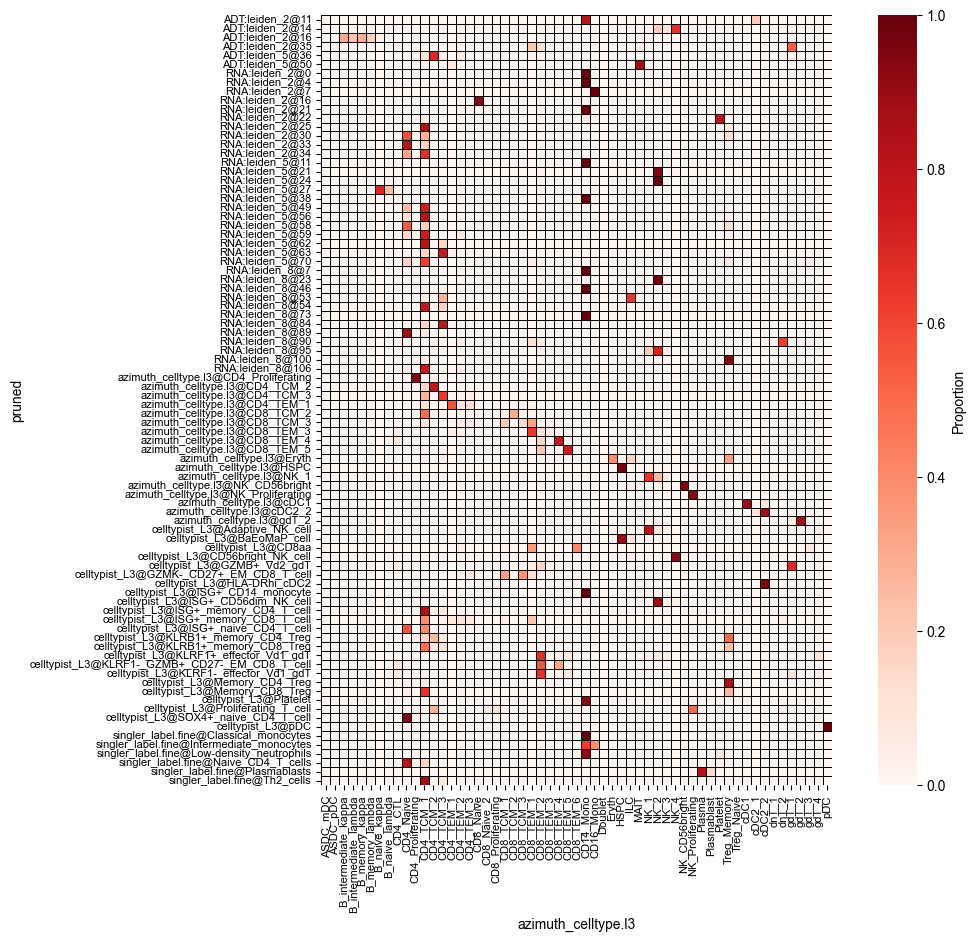

In [6]:
ct = pd.crosstab(adata.obs["pruned"], adata.obs["azimuth_celltype.l3"], normalize="index")
plt.figure(figsize=(12, 10))
sns.heatmap(
  ct,
  fmt=".2f",
  cmap="Reds",
  cbar_kws={"label": "Proportion"},
  xticklabels=ct.columns,
  yticklabels=ct.index,
  square=True,
  linewidths=0.5,
  linecolor="black",
)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

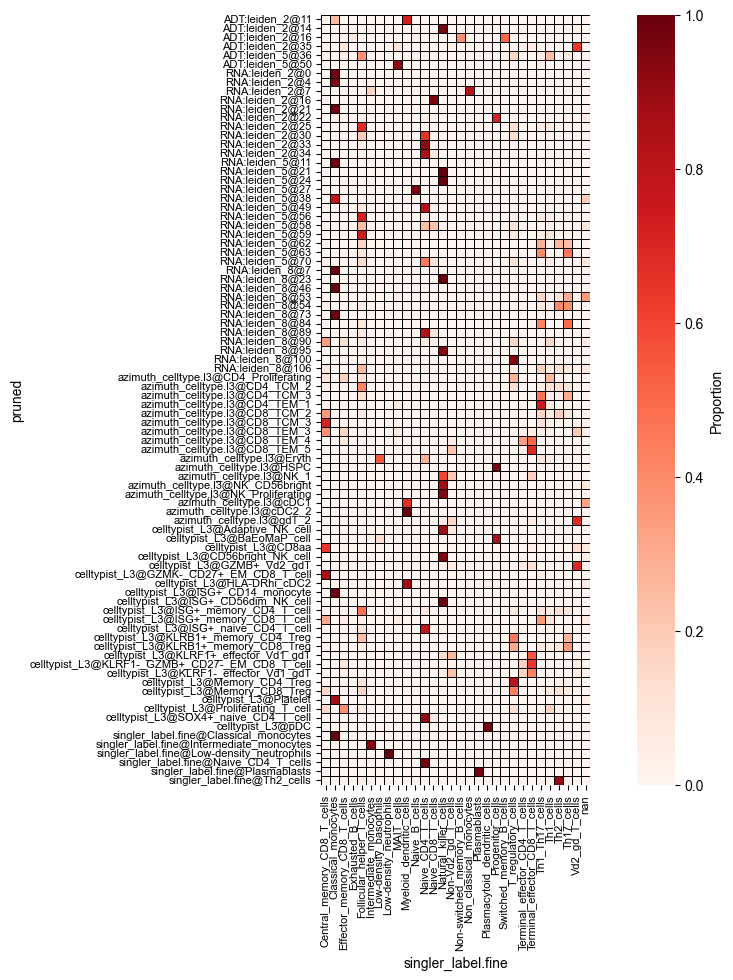

In [7]:
ct = pd.crosstab(adata.obs["pruned"], adata.obs["singler_label.fine"], normalize="index")
plt.figure(figsize=(12, 10))
sns.heatmap(
  ct,
  fmt=".2f",
  cmap="Reds",
  cbar_kws={"label": "Proportion"},
  xticklabels=ct.columns,
  yticklabels=ct.index,
  square=True,
  linewidths=0.5,
  linecolor="black",
)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

### Manually annotate pruned clusters

In [ ]:
cluster_fine = {
    'ADT:leiden_2@11': 'DC_conventional_2',
    'ADT:leiden_2@14': 'NK_CD56dim',
    'ADT:leiden_2@16': 'B_memory',
    'ADT:leiden_2@35': 'T_GD',
    'ADT:leiden_5@36': 'T_CD4_memory_central',
    'ADT:leiden_5@50': 'T_MAIT',
    'RNA:leiden_2@0': 'Mono_CD14',
    'RNA:leiden_2@4': 'Mono_CD14',
    'RNA:leiden_2@7': 'Mono_CD16',
    'RNA:leiden_2@16': 'T_CD8_naive',
    'RNA:leiden_2@21': 'Mono_CD14',
    'RNA:leiden_2@22': 'Platelet',
    'RNA:leiden_2@25': 'T_CD4_memory_central',
    'RNA:leiden_2@30': 'T_CD4_naive',
    'RNA:leiden_2@33': 'T_CD4_naive',
    'RNA:leiden_2@34': 'T_CD4_naive',
    'RNA:leiden_5@11': 'Mono_CD14',
    'RNA:leiden_5@21': 'NK_CD56dim',
    'RNA:leiden_5@24': 'NK_CD56dim',
    'RNA:leiden_5@27': 'B_naive',
    'RNA:leiden_5@38': 'Mono_CD14',
    'RNA:leiden_5@49': 'T_CD4_naive',
    'RNA:leiden_5@56': 'T_CD4_memory_central',
    'RNA:leiden_5@58': 'Artefact',
    'RNA:leiden_5@59': 'T_CD4_memory_central',
    'RNA:leiden_5@62': 'T_CD4_memory_central',
    'RNA:leiden_5@63': 'T_CD4_memory_effector',
    'RNA:leiden_5@70': 'T_CD4_naive',
    'RNA:leiden_8@7': 'Mono_CD14',
    'RNA:leiden_8@23': 'NK_CD56dim',
    'RNA:leiden_8@46': 'Mono_CD14',
    'RNA:leiden_8@53': 'ILC',
    'RNA:leiden_8@54': 'T_CD4_memory_effector',
    'RNA:leiden_8@73': 'Mono_CD14',
    'RNA:leiden_8@84': 'T_CD4_memory_effector',
    'RNA:leiden_8@89': 'T_CD4_naive',
    'RNA:leiden_8@90': 'T_DN',
    'RNA:leiden_8@95': 'NK_CD56dim',
    'RNA:leiden_8@100': 'T_regulatory_memory',
    'RNA:leiden_8@106': 'T_CD4_memory_central',
    'azimuth_celltype.l3@CD4_Proliferating': 'Proliferating',
    'azimuth_celltype.l3@CD4_TCM_2': 'T_CD4_memory_central',
    'azimuth_celltype.l3@CD4_TCM_3': 'T_CD4_memory_effector',
    'azimuth_celltype.l3@CD4_TEM_1': 'T_CD4_memory_effector',
    'azimuth_celltype.l3@CD8_TCM_2': 'T_CD8_memory_central',
    'azimuth_celltype.l3@CD8_TCM_3': 'T_CD8_memory_central',
    'azimuth_celltype.l3@CD8_TEM_3': 'T_CD8_memory_effector',
    'azimuth_celltype.l3@CD8_TEM_4': 'T_CD8_memory_effector',
    'azimuth_celltype.l3@CD8_TEM_5': 'T_CD8_memory_effector',
    'azimuth_celltype.l3@Eryth': 'Erythrocyte',
    'azimuth_celltype.l3@HSPC': 'Progenitor',
    'azimuth_celltype.l3@NK_1': 'NK_CD56dim',
    'azimuth_celltype.l3@NK_CD56bright': 'NK_CD56bright',
    'azimuth_celltype.l3@NK_Proliferating': 'Proliferating',
    'azimuth_celltype.l3@cDC1': 'DC_conventional_1',
    'azimuth_celltype.l3@cDC2_2': 'DC_conventional_2',
    'azimuth_celltype.l3@gdT_2': 'T_GD',
    'celltypist_L3@Adaptive_NK_cell': 'NK_CD56dim',
    'celltypist_L3@BaEoMaP_cell': 'Progenitor',
    'celltypist_L3@CD8aa': 'T_CD8_memory_central',
    'celltypist_L3@CD56bright_NK_cell': 'NK_CD56bright',
    'celltypist_L3@GZMB+_Vd2_gdT': 'T_GD',
    'celltypist_L3@GZMK-_CD27+_EM_CD8_T_cell': 'T_CD8_memory_central',
    'celltypist_L3@HLA-DRhi_cDC2': 'DC_conventional_2',
    'celltypist_L3@ISG+_CD14_monocyte': 'Mono_CD14',
    'celltypist_L3@ISG+_CD56dim_NK_cell': 'NK_CD56dim',
    'celltypist_L3@ISG+_memory_CD4_T_cell': 'T_CD4_memory_central',
    'celltypist_L3@ISG+_memory_CD8_T_cell': 'T_CD8_memory_central',
    'celltypist_L3@ISG+_naive_CD4_T_cell': 'T_CD4_naive',
    'celltypist_L3@KLRB1+_memory_CD4_Treg': 'T_regulatory_memory',
    'celltypist_L3@KLRB1+_memory_CD8_Treg': 'T_regulatory_memory',
    'celltypist_L3@KLRF1+_effector_Vd1_gdT': 'T_CD8_memory_effector',
    'celltypist_L3@KLRF1-_GZMB+_CD27-_EM_CD8_T_cell': 'T_CD8_memory_effector',
    'celltypist_L3@KLRF1-_effector_Vd1_gdT': 'T_CD8_memory_effector',
    'celltypist_L3@Memory_CD4_Treg': 'T_regulatory_memory',
    'celltypist_L3@Memory_CD8_Treg': 'T_regulatory_memory',
    'celltypist_L3@Platelet': 'Platelet',
    'celltypist_L3@Proliferating_T_cell': 'Proliferating',
    'celltypist_L3@SOX4+_naive_CD4_T_cell': 'T_CD4_naive',
    'celltypist_L3@pDC': 'DC_plasmacytoid',
    'singler_label.fine@Classical_monocytes': 'Mono_CD14',
    'singler_label.fine@Intermediate_monocytes': 'Mono_CD14',
    'singler_label.fine@Low-density_neutrophils': 'Granulocyte',
    'singler_label.fine@Naive_CD4_T_cells': 'T_CD4_naive',
    'singler_label.fine@Plasmablasts': 'B_plasma',
    'singler_label.fine@Th2_cells': 'T_CD4_memory_effector',
}
adata.obs["cluster_fine"] = adata.obs["pruned"].map(cluster_fine)
# Manually add cell types misclassified by scTriangulate
adata.obs.loc[adata.obs["RNA:leiden_8"] == "105", "cluster_fine"] = "DC_AXL_SIGLEC6"
adata.obs.loc[adata.obs["RNA:leiden_8"] == "102", "cluster_fine"] = "Proliferating"
# Doublet/artefact clusters (based on marker inspection)
adata.obs.loc[adata.obs["RNA:leiden_8"] == "71", "cluster_fine"] = "Doublet"
adata.obs.loc[adata.obs["RNA:leiden_8"] == "72", "cluster_fine"] = "Artefact"
adata.obs.loc[adata.obs["RNA:leiden_8"] == "74", "cluster_fine"] = "Artefact"
adata.obs.loc[(adata.obs["RNA:leiden_8"] == "16") & (adata.obs["cluster_fine"] != "DC_conventional_1"), "cluster_fine"] = "Doublet"

In [98]:
cluster_coarse = {
    'Artefact': 'Artefact',
    'B_memory': 'B_memory',
    'B_naive': 'B_naive',
    'B_plasma': 'B_plasma',
    'DC_AXL_SIGLEC6': 'DC_AXL_SIGLEC6',
    'DC_conventional_1': 'DC_conventional',
    'DC_conventional_2': 'DC_conventional',
    'DC_plasmacytoid': 'DC_plasmacytoid',
    'Doublet': 'Doublet',
    'Erythrocyte': 'Erythrocyte',
    'Granulocyte': 'Granulocyte',
    'ILC': 'ILC',
    'Mono_CD14': 'Mono_CD14',
    'Mono_CD16': 'Mono_CD16',
    'NK_CD56bright': 'NK_CD56bright',
    'NK_CD56dim': 'NK_CD56dim',
    'Platelet': 'Platelet',
    'Progenitor': 'Progenitor',
    'Proliferating': 'Proliferating',
    'T_CD4_memory_central': 'T_CD4_memory',
    'T_CD4_memory_effector': 'T_CD4_memory',
    'T_CD4_naive': 'T_CD4_naive',
    'T_CD8_memory_central': 'T_CD8_memory',
    'T_CD8_memory_effector': 'T_CD8_memory',
    'T_CD8_naive': 'T_CD8_naive',
    'T_DN': 'T_DN',
    'T_GD': 'T_GD',
    'T_MAIT': 'T_MAIT',
    'T_regulatory_memory': 'T_regulatory_memory',
}
adata.obs["cluster_coarse"] = adata.obs["cluster_fine"].map(cluster_coarse)

In [99]:
cluster_main = {
    'Artefact': 'Artefact',
    'B_memory': 'B',
    'B_naive': 'B',
    'B_plasma': 'B',
    'DC_AXL_SIGLEC6': 'DC',
    'DC_conventional': 'DC',
    'DC_plasmacytoid': 'DC',
    'Doublet': 'Doublet',
    'Erythrocyte': 'Erythrocyte',
    'Granulocyte': 'Granulocyte',
    'ILC': 'ILC',
    'Mono_CD14': 'Mono',
    'Mono_CD16': 'Mono',
    'NK_CD56bright': 'NK',
    'NK_CD56dim': 'NK',
    'Platelet': 'Platelet',
    'Progenitor': 'Progenitor',
    'Proliferating': 'Proliferating',
    'T_CD4_memory': 'T',
    'T_CD4_naive': 'T',
    'T_CD8_memory': 'T',
    'T_CD8_naive': 'T',
    'T_DN': 'T',
    'T_GD': 'T',
    'T_MAIT': 'T',
    'T_regulatory_memory': 'T',
    'T_regulatory_naive': 'T'
}
adata.obs["cluster_main"] = adata.obs["cluster_coarse"].map(cluster_main)

### Visualise cluster annotations

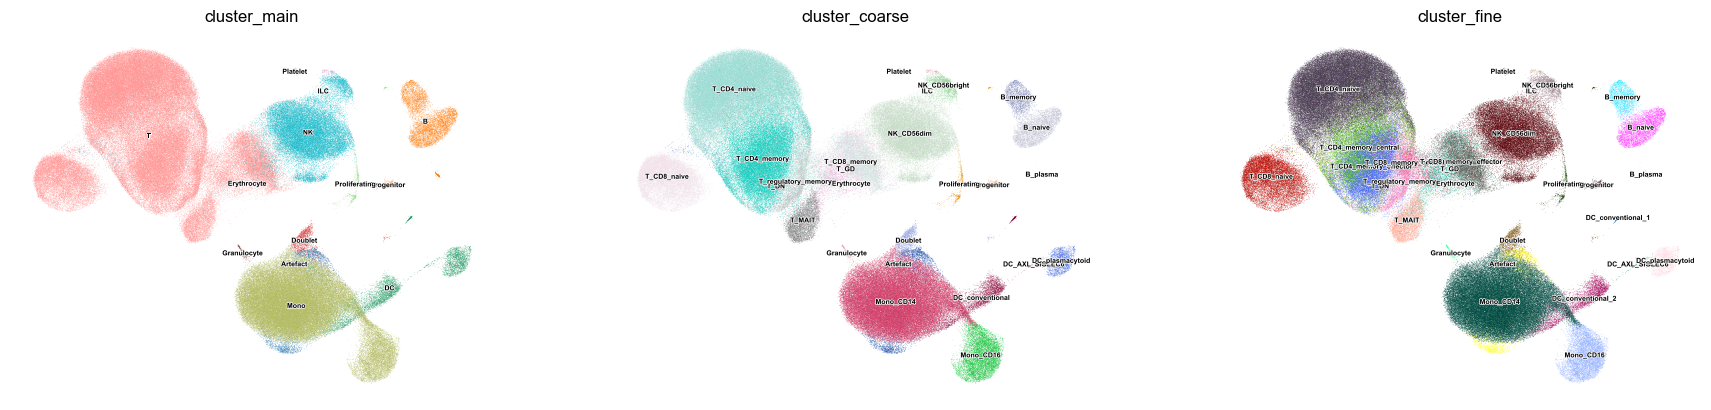

In [106]:
sc.pl.umap(
    adata,
    color=["cluster_main", "cluster_coarse", "cluster_fine"],
    frameon=False,
    legend_loc="on data",
    legend_fontoutline=1,
    legend_fontsize=5,
    ncols=3,
)

### Save cluster annotations

In [107]:
adata.obs[["cluster_main", "cluster_coarse", "cluster_fine"]].to_csv(os.path.join(results_dir, "cluster_annotation.tsv"), sep="\t", index=True, header=True)